# Dataset description
## Number of submission to justice per year

**Source**: MinDefensa

**Download**: [link](https://www.datos.gov.co/Seguridad-y-Defensa/SOMETIMIENTO-INDIVIDUAL-A-LA-JUSTICIA/xg7g-dzk4/about_data)

# Code
## Imports

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [41]:
path = "./data/SOMETIMIENTO_INDIVIDUAL_A_LA_JUSTICIA_20260918.csv"

cols = [
    "FECHA", "GRUPO"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [42]:
df["CANTIDAD"] = 1
df["FECHA"] = df["FECHA"].str.split(" ").str[0].astype(int)

by_year = df.groupby("FECHA").sum(numeric_only=True).drop([2020, 2026])

## Plot

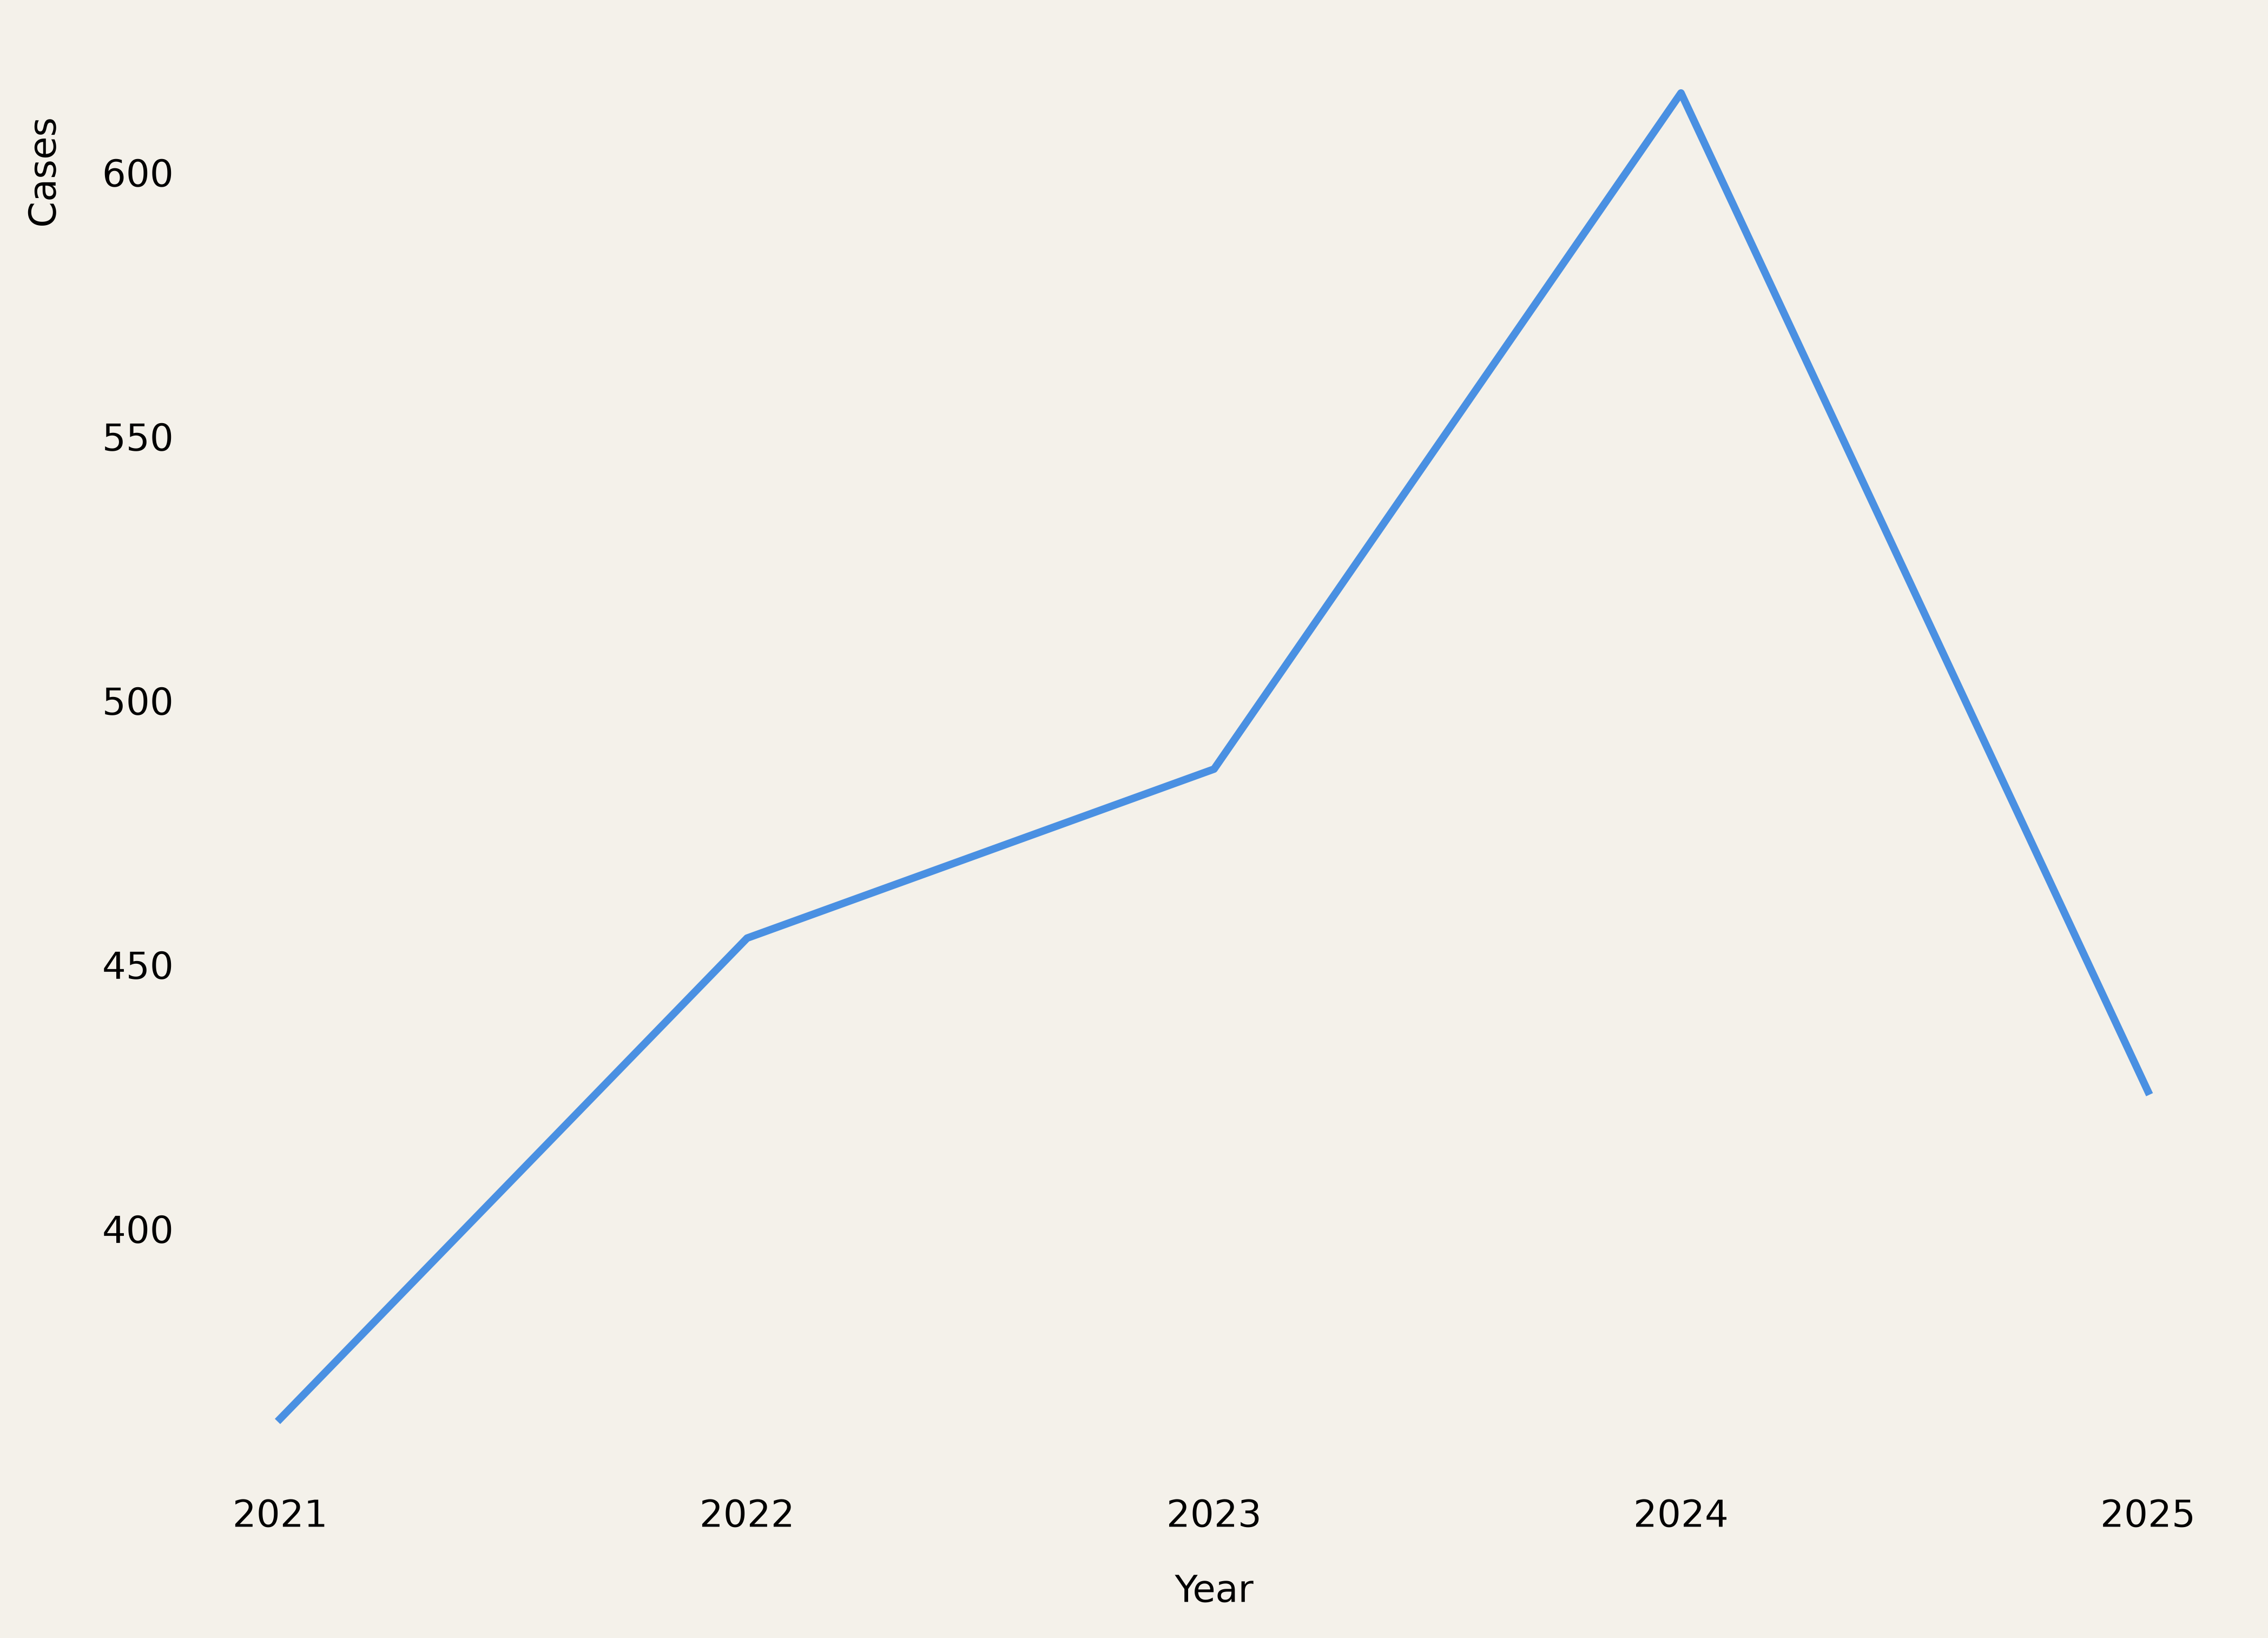

In [43]:
background = "#F4F1EA"
blue = "#4a90e2"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(by_year, linewidth=2, color=blue)
plt.xticks(by_year.index)

plt.ylabel("Cases", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.show()

In [44]:
group = df.groupby("GRUPO")["CANTIDAD"].sum()
group

GRUPO
CAPARROS             7
CLAN DEL GOLFO     890
GAOR              1650
PELUSOS              6
SIN ESTABLECER       2
Name: CANTIDAD, dtype: int64